## Introduction
The heterogeneity of responses to resistance exercise training (RT) is well documented, yet most protocol adopts a one-size-fits-all approach. To be able to offer personalised RT regimens, this study is aimed at predicting individual hypertrophic response to RT based on muscle transcriptomic data of the 460 vastus lateralis samples obtained from 232 participants. 

Three different predition models  each having a balanced accuracy of approximately 0.6 were stacked to build a single model hoping to improve the model's ability to classify an individual as a potential non-responder, average_responder or high_responder

In [1]:

import os
import json
import pickle
from pathlib import Path
from typing import List, Optional, Tuple, Dict
import seaborn as sns
import matplotlib.pyplot as plt

import numpy as np
import pandas as pd

from sklearn.model_selection import StratifiedGroupKFold
from sklearn.preprocessing import StandardScaler
from sklearn.utils.class_weight import compute_class_weight, compute_sample_weight
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.metrics import f1_score, classification_report, confusion_matrix, accuracy_score, matthews_corrcoef

import lightgbm as lgb
from lightgbm import LGBMClassifier
from xgboost import XGBClassifier
import shap


In [2]:
RANDOM_STATE = 42

The dataset has been preprocessed to classify those with less than 1% percentage change in muscle mass as "No_responders", those at the 90th percentile and above of the percentage changes in the individual studies as "High_responders"; while the rest are classified as "Average_responders". The preprocessing steps is as shown in the file "Preprocessing.ipynb".

This data contains the gene expression counts (normalised for library size), age, sample_id, BMI, of participants as well as RNA sequencing_depth of each study ; and volume of RT


In [3]:
# load the dataset.
df = pd.read_csv("./dataset_for_classification_model.csv")
# exclude Volume data
#pattern = "vol_"
#df = df[~df["participant"].str.contains(pattern, regex = False)]
df

,participant,seq_sample_id,age,BMI,category,sequencing_depth,volume,condition,TSPAN6,DPM1,...,ENSG00000309174,ENSG00000309618,ENSG00000310376,CAST,ENSG00000310523,WASH7P,WASH9P,ENSG00000310533,sex_female,sex_male
0,vol_FP11,FP11w0L,22.3,23.6,No_responder,1.51,1,RM10,3.85,30.23,...,2.95,5.89,1125.84,230.96,5.93,11.60,5.07,1.88,0,1
1,vol_FP11,FP11w0R,22.3,23.6,No_responder,1.51,3,RM10,4.72,27.63,...,3.75,4.72,1057.75,243.95,5.91,11.36,3.96,2.30,0,1
2,vol_FP12,FP12w0L,21.3,22.8,No_responder,1.51,1,RM10,5.48,32.51,...,2.91,7.09,614.65,143.06,7.21,7.53,7.33,2.78,1,0
3,vol_FP12,FP12w0R,21.3,22.8,No_responder,1.51,3,RM10,5.88,28.35,...,2.41,10.94,584.76,142.61,7.23,15.26,9.02,1.10,1,0
4,vol_FP13,FP13w0L,22.7,19.8,High_responder,1.51,3,RM10,5.59,34.57,...,2.29,6.95,724.77,158.42,3.87,16.90,13.56,5.87,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
456,Alpha/Omega_693,s891,54.0,21.8,Average_responder,2.35,3,RM30,3.94,18.93,...,4.78,1.79,12.13,131.02,17.86,29.32,28.00,3.93,1,0
457,Alpha/Omega_694,s903,42.0,27.3,High_responder,2.35,3,RM30,4.37,18.69,...,3.86,2.01,12.21,126.66,13.64,27.64,18.58,1.20,1,0
458,Alpha/Omega_694,s903,42.0,27.3,Average_responder,2.35,3,RM10,4.37,18.69,...,3.86,2.01,12.21,126.66,13.64,27.64,18.58,1.20,1,0
459,Alpha/Omega_515,s96,48.0,27.7,Average_responder,2.35,3,RM10,4.69,25.65,...,1.94,1.73,37.61,151.40,15.83,24.10,27.72,3.25,0,1


<Axes: xlabel='category', ylabel='count'>

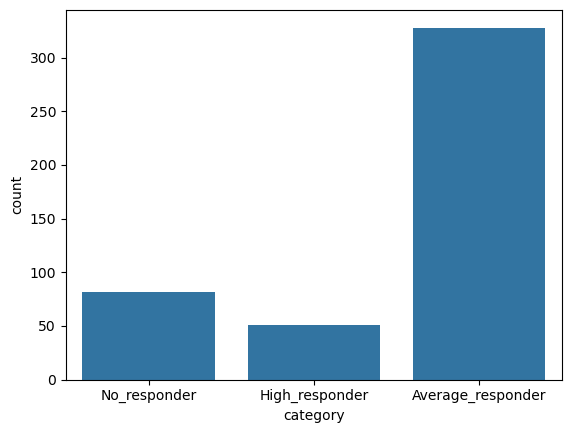

In [4]:
# Visualize the response varaible
sns.countplot(x = df["category"])

In [5]:
# Define predictor variables (drop sample ID and response category)
X = df.drop(["seq_sample_id", "category", "participant", "condition"], axis=1)

# Encode response variable
y = df["category"].map({'No_responder': 0, 'Average_responder': 1, 'High_responder': 2})
group = df["participant"] # define participant as grouping variable as most had two samples


# Initialize StratifiedGroupKFold
cv = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

# Get train/test split from the first fold
for train_idx, test_idx in cv.split(X, y, group ): 
    X_train_full, X_test = X.iloc[train_idx], X.iloc[test_idx]
    y_train_full, y_test = y.iloc[train_idx], y.iloc[test_idx]
    break  # Use only the first fold for train/test split

# Optional: split training set into train/validation using another fold
cv_inner = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
for train_idx, val_idx in cv_inner.split(X_train_full, y_train_full, group.iloc[train_idx]):
    X_train, X_val = X_train_full.iloc[train_idx], X_train_full.iloc[val_idx]
    y_train, y_val = y_train_full.iloc[train_idx], y_train_full.iloc[val_idx]
    break

# Columns to exclude from scaling
exclude_cols = [#"BMI", "age", "volume",
                "sex_female", "sex_male"]

# Separate columns to scale
X_train_to_scale = X_train.drop(columns=exclude_cols)
X_val_to_scale = X_val.drop(columns=exclude_cols)
X_test_to_scale = X_test.drop(columns=exclude_cols)

# Scale only the selected columns
scaler = StandardScaler()
X_train_scaled_part = scaler.fit_transform(X_train_to_scale)
X_val_scaled_part = scaler.transform(X_val_to_scale)
X_test_scaled_part = scaler.transform(X_test_to_scale)

# Convert scaled arrays back to DataFrames
X_train_scaled_part = pd.DataFrame(X_train_scaled_part, columns=X_train_to_scale.columns, index=X_train.index)
X_val_scaled_part = pd.DataFrame(X_val_scaled_part, columns=X_val_to_scale.columns, index=X_val.index)
X_test_scaled_part = pd.DataFrame(X_test_scaled_part, columns=X_test_to_scale.columns, index=X_test.index)

# Reappend the excluded columns
X_train_scaled = pd.concat([X_train_scaled_part, X_train[exclude_cols]], axis=1)
X_val_scaled = pd.concat([X_val_scaled_part, X_val[exclude_cols]], axis=1)
X_test_scaled = pd.concat([X_test_scaled_part, X_test[exclude_cols]], axis=1)

# Print shapes
print(f"Training feature shape: {X_train_scaled.shape}")
print(f"Validation feature shape: {X_val_scaled.shape}")
print(f"Test feature shape: {X_test_scaled.shape}")


Training feature shape: (296, 11231)
Validation feature shape: (73, 11231)
Test feature shape: (92, 11231)


In [6]:
# Dataset is imbalanced , use class weight to ensure model pays attention to minority classes (No_responder and High_responder)
class_weights = compute_class_weight(
    class_weight="balanced",
    classes=np.unique(y_train),
    y=y_train
)

class_weight_dict = dict(enumerate(class_weights))

In [7]:
# configuration
USE_GPU = False                   
EARLY_STOPPING_ROUNDS = 100
N_ESTIMATORS_MAX = 5000           # upper bound (early stopping will stop earlier)
N_ITER = 30                       # random search trials
VERBOSE_LGB_EVAL = False          # per-iteration logging off


# sklearn-style custom metric suitable for LGBM
def macro_f1_sklearn(y_true, y_pred):
    """
    Custom eval metric for LightGBM scikit-learn API.
    Works for multiclass; accepts raw scores or probabilities.
    Returns (name, value, higher_is_better).
    """
    y_true = np.asarray(y_true).astype(int)
    y_pred = np.asarray(y_pred)

    if y_pred.ndim == 1:
        n_samples = y_true.shape[0]
        n_classes = int(y_pred.size // n_samples)
        y_prob = y_pred.reshape(n_samples, n_classes)
    else:
        y_prob = y_pred  # (N, C)

    y_hat = y_prob.argmax(axis=1)

    f1 = f1_score(y_true, y_hat, average="macro", zero_division=0)
    return "macro_f1", f1, True

#Recover readable class names in the correct order (0,1,2)
idx_to_class = {0: "No_responder", 1: "Average_responder", 2: "High_responder"}
class_names = [idx_to_class[i] for i in sorted(idx_to_class)]


In [8]:
# Define callbacks/earlystopping
callbacks = [lgb.early_stopping(EARLY_STOPPING_ROUNDS, verbose=VERBOSE_LGB_EVAL)]
if not VERBOSE_LGB_EVAL:
    callbacks.append(lgb.log_evaluation(period=0))

lgbm = LGBMClassifier(
    objective="multiclassova",
  #  boosting_type= "rf",
    num_class=3,                   
    n_estimators=3000,             # large upper bound; early stopping will cut short
    random_state=RANDOM_STATE,
    n_jobs=-1,         
     class_weight=class_weight_dict,  
    learning_rate=0.021, #0.021
    num_leaves=10, # 10
   # max_depth = 100,
    feature_fraction=0.65,
    bagging_fraction=0.75, 
    bagging_freq=1,
    min_data_in_leaf=10, 
    reg_lambda=0.001, 
    reg_alpha = 0.05, #0.01
    min_gain_to_split= 0.1,
    verbosity = -1 # suppress log output
)


lgbm.fit(
    X_train_scaled, y_train,
    eval_set=[(X_val_scaled, y_val)],
    eval_metric=macro_f1_sklearn,      # use sklearn-style custom metric
    callbacks=callbacks,

)

# Evaluate on validation dataset
probs_val = lgbm.predict_proba(X_val_scaled, num_iteration=lgbm.best_iteration_)
pred_val = probs_val.argmax(axis=1)
print(f" Val macro-F1: {f1_score(y_val, pred_val, average='macro'):.4f}")

print(classification_report(
    y_val, pred_val,
    target_names=["No_responder", "Average_responder", "High_responder"],
    digits=2, zero_division=0
))
print(f" Matthews correlation coefficient: {matthews_corrcoef(y_val,pred_val) :.4f}")

 Val macro-F1: 0.5635
                   precision    recall  f1-score   support

     No_responder       0.70      0.54      0.61        13
Average_responder       0.80      0.92      0.86        53
   High_responder       0.50      0.14      0.22         7

         accuracy                           0.78        73
        macro avg       0.67      0.54      0.56        73
     weighted avg       0.76      0.78      0.75        73

 Matthews correlation coefficient: 0.4213


In [9]:
# How many features were relevant for the model
used_features = (lgbm.booster_.feature_importance(importance_type="gain") > 0).sum()
print(f"Features used in splits: {used_features} / {len(lgbm.booster_.feature_name())}")

Features used in splits: 181 / 11231


In [10]:
# Trained model: lgbm (sklearn wrapper)
booster = lgbm.booster_
num_class = len(lgbm.classes_)  
class_names = ["No_responder", "Average_responder", "High_responder"]

# Extract trees as DataFrame
df_ = booster.trees_to_dataframe()

# Restrict to trees used up to best_iteration
if getattr(lgbm, "best_iteration_", None) is not None:
    df_ = df_[df_["tree_index"] < lgbm.best_iteration_ * num_class]

# Keep only split nodes
df_ = df_[~df_["split_feature"].isna()].copy()

# Map tree
df_["class_id"] = (df_["tree_index"] % num_class).astype(int)

# Aggregate split_gain per (class, feature)
gain_pc = (
    df_.groupby(["class_id", "split_feature"])["split_gain"]
      .sum().reset_index().rename(columns={"split_gain": "gain"})
)
gain_pc["class_name"] = gain_pc["class_id"].map({i:n for i,n in enumerate(class_names)})
gain_pc.sort_values(["class_id","gain"], ascending=[True,False])

,class_id,split_feature,gain,class_name
20,0,GDPD1,80.053902,No_responder
59,0,TM9SF1,52.019699,No_responder
5,0,ATG16L1,45.073200,No_responder
1,0,ADAR,41.088402,No_responder
19,0,FOXRED2,39.008799,No_responder
...,...,...,...,...
155,2,NDRG4,5.798610,High_responder
175,2,TENT4A,4.145600,High_responder
135,2,CDADC1,3.434760,High_responder
181,2,ZSCAN25,2.450650,High_responder


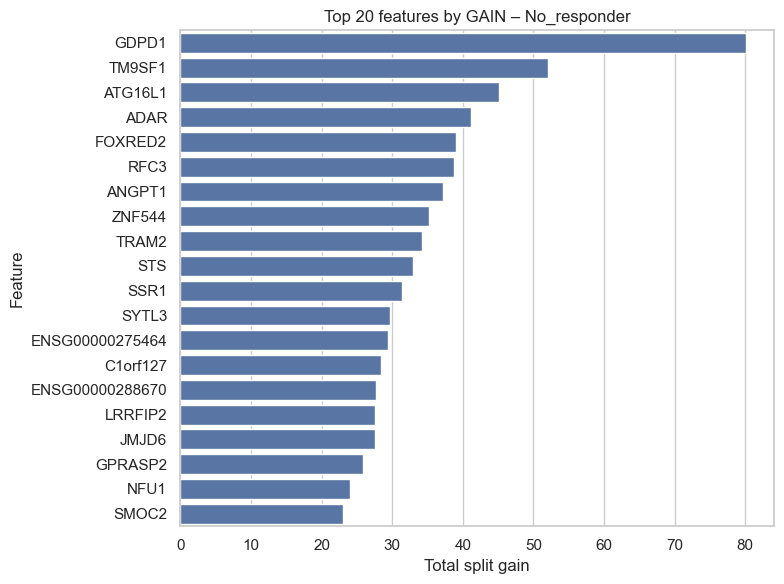

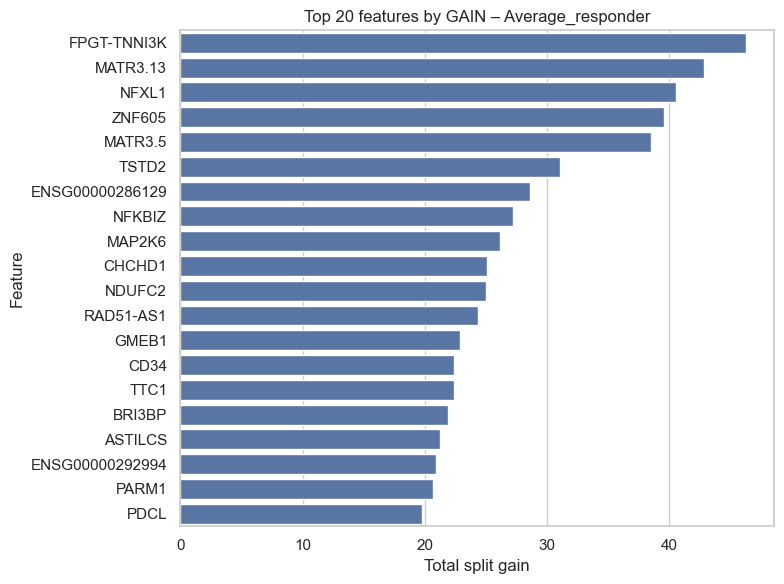

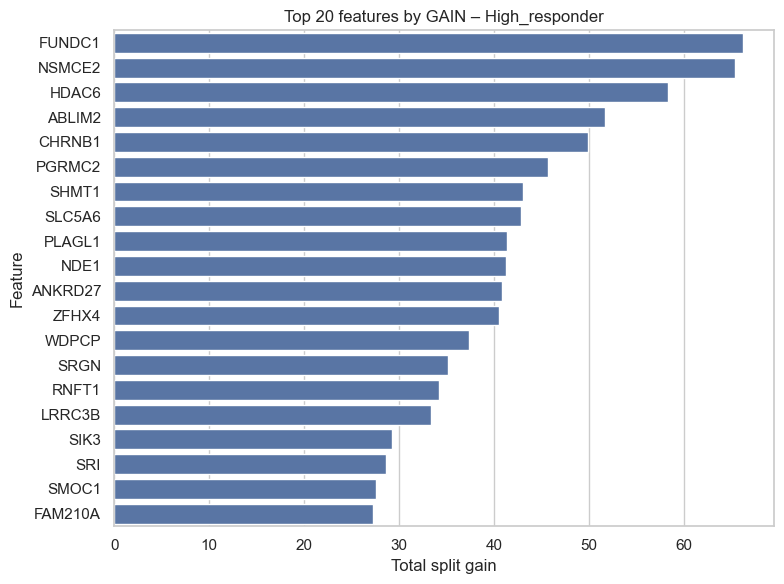

In [11]:
# Plot top-20 per class
TOP_K = 20
sns.set(style="whitegrid")
for c in range(num_class):
    data = (gain_pc[gain_pc["class_id"] == c]
            .sort_values("gain", ascending=False).head(TOP_K))
    plt.figure(figsize=(8, max(4, 0.3*len(data))))
    sns.barplot(data=data, y="split_feature", x="gain", color="#4C72B0")
    plt.title(f"Top {TOP_K} features by GAIN – {class_names[c]}")
    plt.xlabel("Total split gain")
    plt.ylabel("Feature")
    plt.tight_layout()
    plt.show()


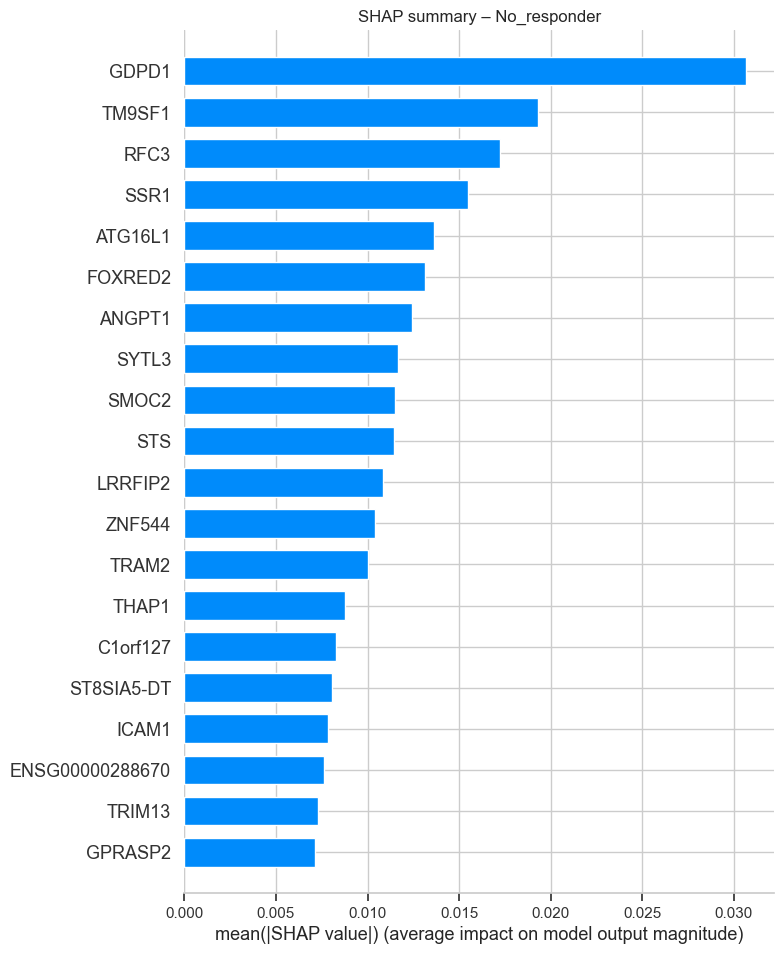

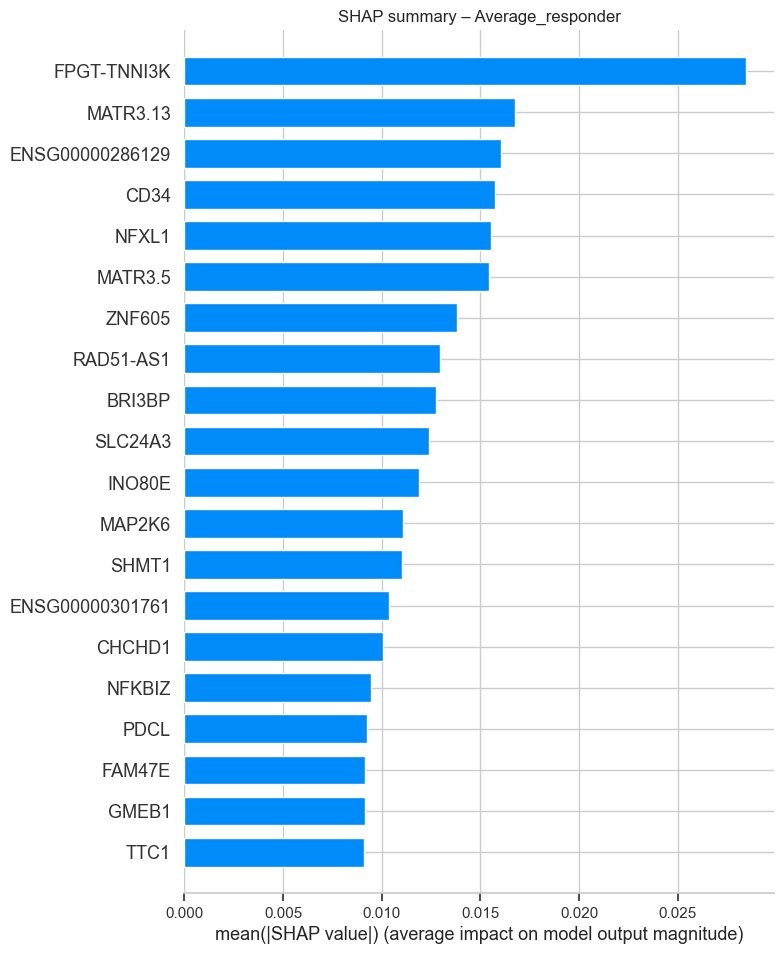

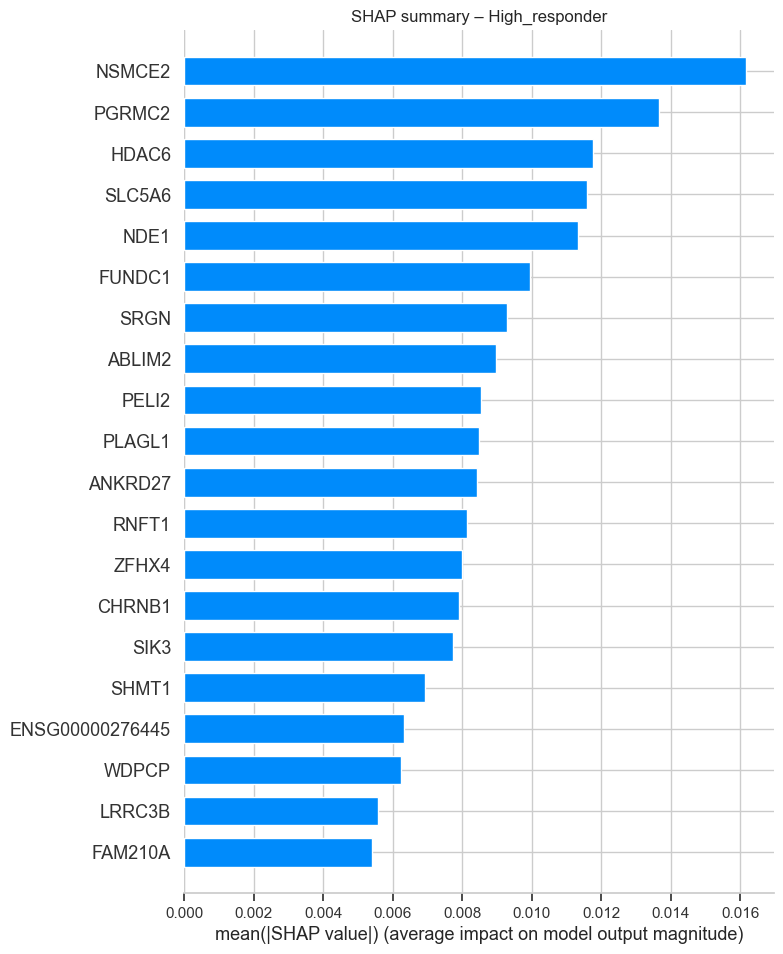

In [12]:

feature_names = lgbm.booster_.feature_name()

explainer = shap.TreeExplainer(lgbm.booster_)
shap_values = explainer.shap_values(X_val_scaled) 

for c, name in enumerate(class_names):
    sv_c = shap_values[:, :, c]  
    shap.summary_plot(
        sv_c, X_val_scaled,
        feature_names=feature_names,
        plot_type="bar",     
        max_display=20,       
        show=False
    )
    plt.title(f"SHAP summary – {name}")
    plt.show()



In [13]:
#preds = lgbm.predict_proba(X_test_scaled)
#pred = preds.argmax(axis=1)
#print(f" Test macro-F1: {f1_score(y_test, pred, average='macro'):.4f}")

#print(classification_report(
#    y_test, pred,
#    target_names=["No_responder", "Average_responder", "High_responder"],
#    digits=3, zero_division=0
#))

##  Feature selection

The features deemed important for the model will be used to train a new model

In [14]:
#important_features = gain_pc["split_feature"]
#important_features

In [15]:
# Use the important features to retrain the model
#X_train_reduced = X_train_scaled[important_features]
#X_val_reduced = X_val_scaled[important_features]
#X_test_reduced = X_test_scaled[important_features]

# Remove duplicate columns from scaled datasets
#X_train_reduced = X_train_reduced.loc[:, ~X_train_reduced.columns.duplicated()]
#X_val_reduced = X_val_reduced.loc[:, ~X_val_reduced.columns.duplicated()]
#X_test_reduced = X_test_reduced.loc[:, ~X_test_reduced.columns.duplicated()]

# Print shapes
#print(f"Training feature shape: {X_train_reduced.shape}")
#print(f"Validation feature shape: {X_val_reduced.shape}")
#print(f"Test feature shape: {X_test_reduced.shape}")

In [16]:
# Initialize and train another model

#lgbm_retrained = LGBMClassifier(
#    objective="multiclassova",
 #   num_class=3,                   
  #  n_estimators=3000,             # large upper bound; early stopping will cut short
 #   random_state=RANDOM_STATE,
 #   n_jobs=-1,         
 #    class_weight=class_weight_dict,  
 #   learning_rate=0.1, 
 #   num_leaves=13, 
 #   feature_fraction=0.75,
#    bagging_fraction=0.75, 
 #   bagging_freq=1,
 #   min_data_in_leaf=3, 
 #   reg_lambda=0.001, 
 #   reg_alpha = 0.05, #0.01
#    min_gain_to_split= 0.01,
#    verbosity = -1 # suppress log output
#)


#lgbm_retrained.fit(
#    X_train_reduced, y_train,
 #   eval_set=[(X_val_reduced, y_val)],
 #   eval_metric=macro_f1_sklearn,      # use sklearn-style custom metric
 #   callbacks=callbacks,

#)

# Evaluate on validation dataset
#probs_val_re= lgbm_retrained.predict_proba(X_val_reduced, num_iteration=lgbm_retrained.best_iteration_)
#pred_val_re = probs_val_re.argmax(axis=1)
#print(f" Retrained macro-F1: {f1_score(y_val, pred_val_re, average='macro'):.4f}")

#print(classification_report(
#    y_val, pred_val_re,
#    target_names=["No_responder", "Average_responder", "High_responder"],
#    digits=2, zero_division=0
#))
#print(f" Matthews correlation coefficient: {matthews_corrcoef(y_val, pred_val_re) :.4f}")